# Thiranex Data Science Internship — Task 3
## Project Title: World Happiness & Socioeconomic Exploratory Data Analysis (EDA)
**Author:** Data Science Intern  
**Domain:** World Happiness / Socioeconomic Analysis  
**Dataset:** World Happiness Report 2021 Dataset  
**Due Date:** 16 October 2026  
***

### 1. Executive Summary & Project Objectives
Understanding the global drivers of subjective well-being is vital for policymakers, economists, and international development organizations. The **World Happiness Report 2021** quantifies national happiness scores (Cantril Ladder) across 149 nations based on economic output, social support, health, freedom, generosity, and public trust.

**Core Objectives:**
1. **Data Understanding & Quality Audit**: Structural inspection of 149 country records across 9 core socioeconomic dimensions.
2. **Univariate Analysis**: Statistical distribution metrics (mean, median, IQR, skewness) for all numerical variables.
3. **Bivariate & Multivariate Analysis**: Quantify relationships between happiness scores and key drivers using Pearson ($r$) and Spearman ($ho$) correlation matrices.
4. **Regional Comparison**: Analyze socioeconomic disparities across 10 world regions.
5. **Data Storytelling**: Generate publication-grade visual reports and business/policy recommendations.


---
### 2. Environment Setup & Library Imports
We import core scientific computing libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy.stats`), along with modular functions from `src/analysis.py`.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

# Add project root to sys.path
sys.path.append(os.path.abspath(".."))

from src.analysis import (
    load_raw_data,
    inspect_data,
    clean_dataframe,
    compute_univariate_stats,
    compute_correlations,
    plot_happiness_distribution,
    plot_regional_boxplot,
    plot_gdp_vs_happiness,
    plot_correlation_heatmap,
    plot_top10_bottom10_countries,
    plot_regional_mean_happiness,
    plot_key_drivers_scatter_grid,
    plot_correlation_comparison
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
%matplotlib inline

print("Task 3 Libraries and analysis module successfully imported!")


Task 3 Libraries and analysis module successfully imported!


---
### 3. Data Loading & Ingestion
We load the original raw dataset from `data/raw/world-happiness-report-2021.csv`.


In [2]:
raw_data_path = os.path.join("..", "data", "raw", "world-happiness-report-2021.csv")
df_raw = load_raw_data(raw_data_path)

print(f"Dataset Shape: {df_raw.shape[0]} countries x {df_raw.shape[1]} features")


[INFO] Loading raw World Happiness dataset from: ..\data\raw\world-happiness-report-2021.csv
[INFO] Raw dataset loaded successfully. Shape: (149, 20)
Dataset Shape: 149 countries x 20 features


In [3]:
# Preview head and tail
print("--- Top 5 Records ---")
display(df_raw.head())


--- Top 5 Records ---


,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.8420,0.0320,7.9040,7.7800,10.7750,0.9540,72.0000,0.9490,-0.0980,0.1860,2.4300,1.4460,1.1060,0.7410,0.6910,0.1240,0.4810,3.2530
1,Denmark,Western Europe,7.6200,0.0350,7.6870,7.5520,10.9330,0.9540,72.7000,0.9460,0.0300,0.1790,2.4300,1.5020,1.1080,0.7630,0.6860,0.2080,0.4850,2.8680
2,Switzerland,Western Europe,7.5710,0.0360,7.6430,7.5000,11.1170,0.9420,74.4000,0.9190,0.0250,0.2920,2.4300,1.5660,1.0790,0.8160,0.6530,0.2040,0.4130,2.8390
3,Iceland,Western Europe,7.5540,0.0590,7.6700,7.4380,10.8780,0.9830,73.0000,0.9550,0.1600,0.6730,2.4300,1.4820,1.1720,0.7720,0.6980,0.2930,0.1700,2.9670
4,Netherlands,Western Europe,7.4640,0.0270,7.5180,7.4100,10.9320,0.9420,72.4000,0.9130,0.1750,0.3380,2.4300,1.5010,1.0790,0.7530,0.6470,0.3020,0.3840,2.7980


---
### 4. Data Quality Audit & Cleaning
We audit data types, verify missing values, rename columns to clean standard conventions, and save `cleaned_happiness_2021.csv`.


In [4]:
inspection = inspect_data(df_raw)
print("Duplicate Rows:", inspection['duplicate_rows'])

df_clean, tracking = clean_dataframe(df_raw)
processed_path = os.path.join("..", "data", "processed", "cleaned_happiness_2021.csv")
df_clean.to_csv(processed_path, index=False)

print("Cleaned Dataset Shape:", df_clean.shape)
display(df_clean.head())


Duplicate Rows: 0
Cleaned Dataset Shape: (149, 9)


,Country,Region,HappinessScore,LogGDP,SocialSupport,HealthyLifeExpectancy,Freedom,Generosity,CorruptionPerception
0,Finland,Western Europe,7.8420,10.7750,0.9540,72.0000,0.9490,-0.0980,0.1860
1,Denmark,Western Europe,7.6200,10.9330,0.9540,72.7000,0.9460,0.0300,0.1790
2,Switzerland,Western Europe,7.5710,11.1170,0.9420,74.4000,0.9190,0.0250,0.2920
3,Iceland,Western Europe,7.5540,10.8780,0.9830,73.0000,0.9550,0.1600,0.6730
4,Netherlands,Western Europe,7.4640,10.9320,0.9420,72.4000,0.9130,0.1750,0.3380


---
### 5. Univariate Statistical Analysis
We compute comprehensive descriptive statistics (Mean, Median, StdDev, Min, Max, Q25, Q75, IQR, Skewness) for each numerical variable.


In [5]:
df_univariate = compute_univariate_stats(df_clean)

print("=== UNIVARIATE STATISTICAL SUMMARY ===")
display(df_univariate)


=== UNIVARIATE STATISTICAL SUMMARY ===


,Variable,Mean,Median,StdDev,Min,Q25 (25%),Q75 (75%),Max,IQR,Skewness
0,HappinessScore,5.5328,5.5340,1.0739,2.5230,4.8520,6.2550,7.8420,1.4030,-0.1043
1,LogGDP,9.4322,9.5690,1.1586,6.6350,8.5410,10.4210,11.6470,1.8800,-0.3520
2,SocialSupport,0.8147,0.8320,0.1149,0.4630,0.7500,0.9050,0.9830,0.1550,-0.9378
3,HealthyLifeExpectancy,64.9928,66.6030,6.7620,48.4780,59.8020,69.6000,76.9530,9.7980,-0.5220
4,Freedom,0.7916,0.8040,0.1133,0.3820,0.7180,0.8770,0.9700,0.1590,-0.7548
5,Generosity,-0.0151,-0.0360,0.1507,-0.2880,-0.1260,0.0790,0.5420,0.2050,1.0100
6,CorruptionPerception,0.7274,0.7810,0.1792,0.0820,0.6670,0.8450,0.9390,0.1780,-1.5775


[SAVED] Happiness distribution plot saved to: ..\visualizations\01_happiness_distribution.png


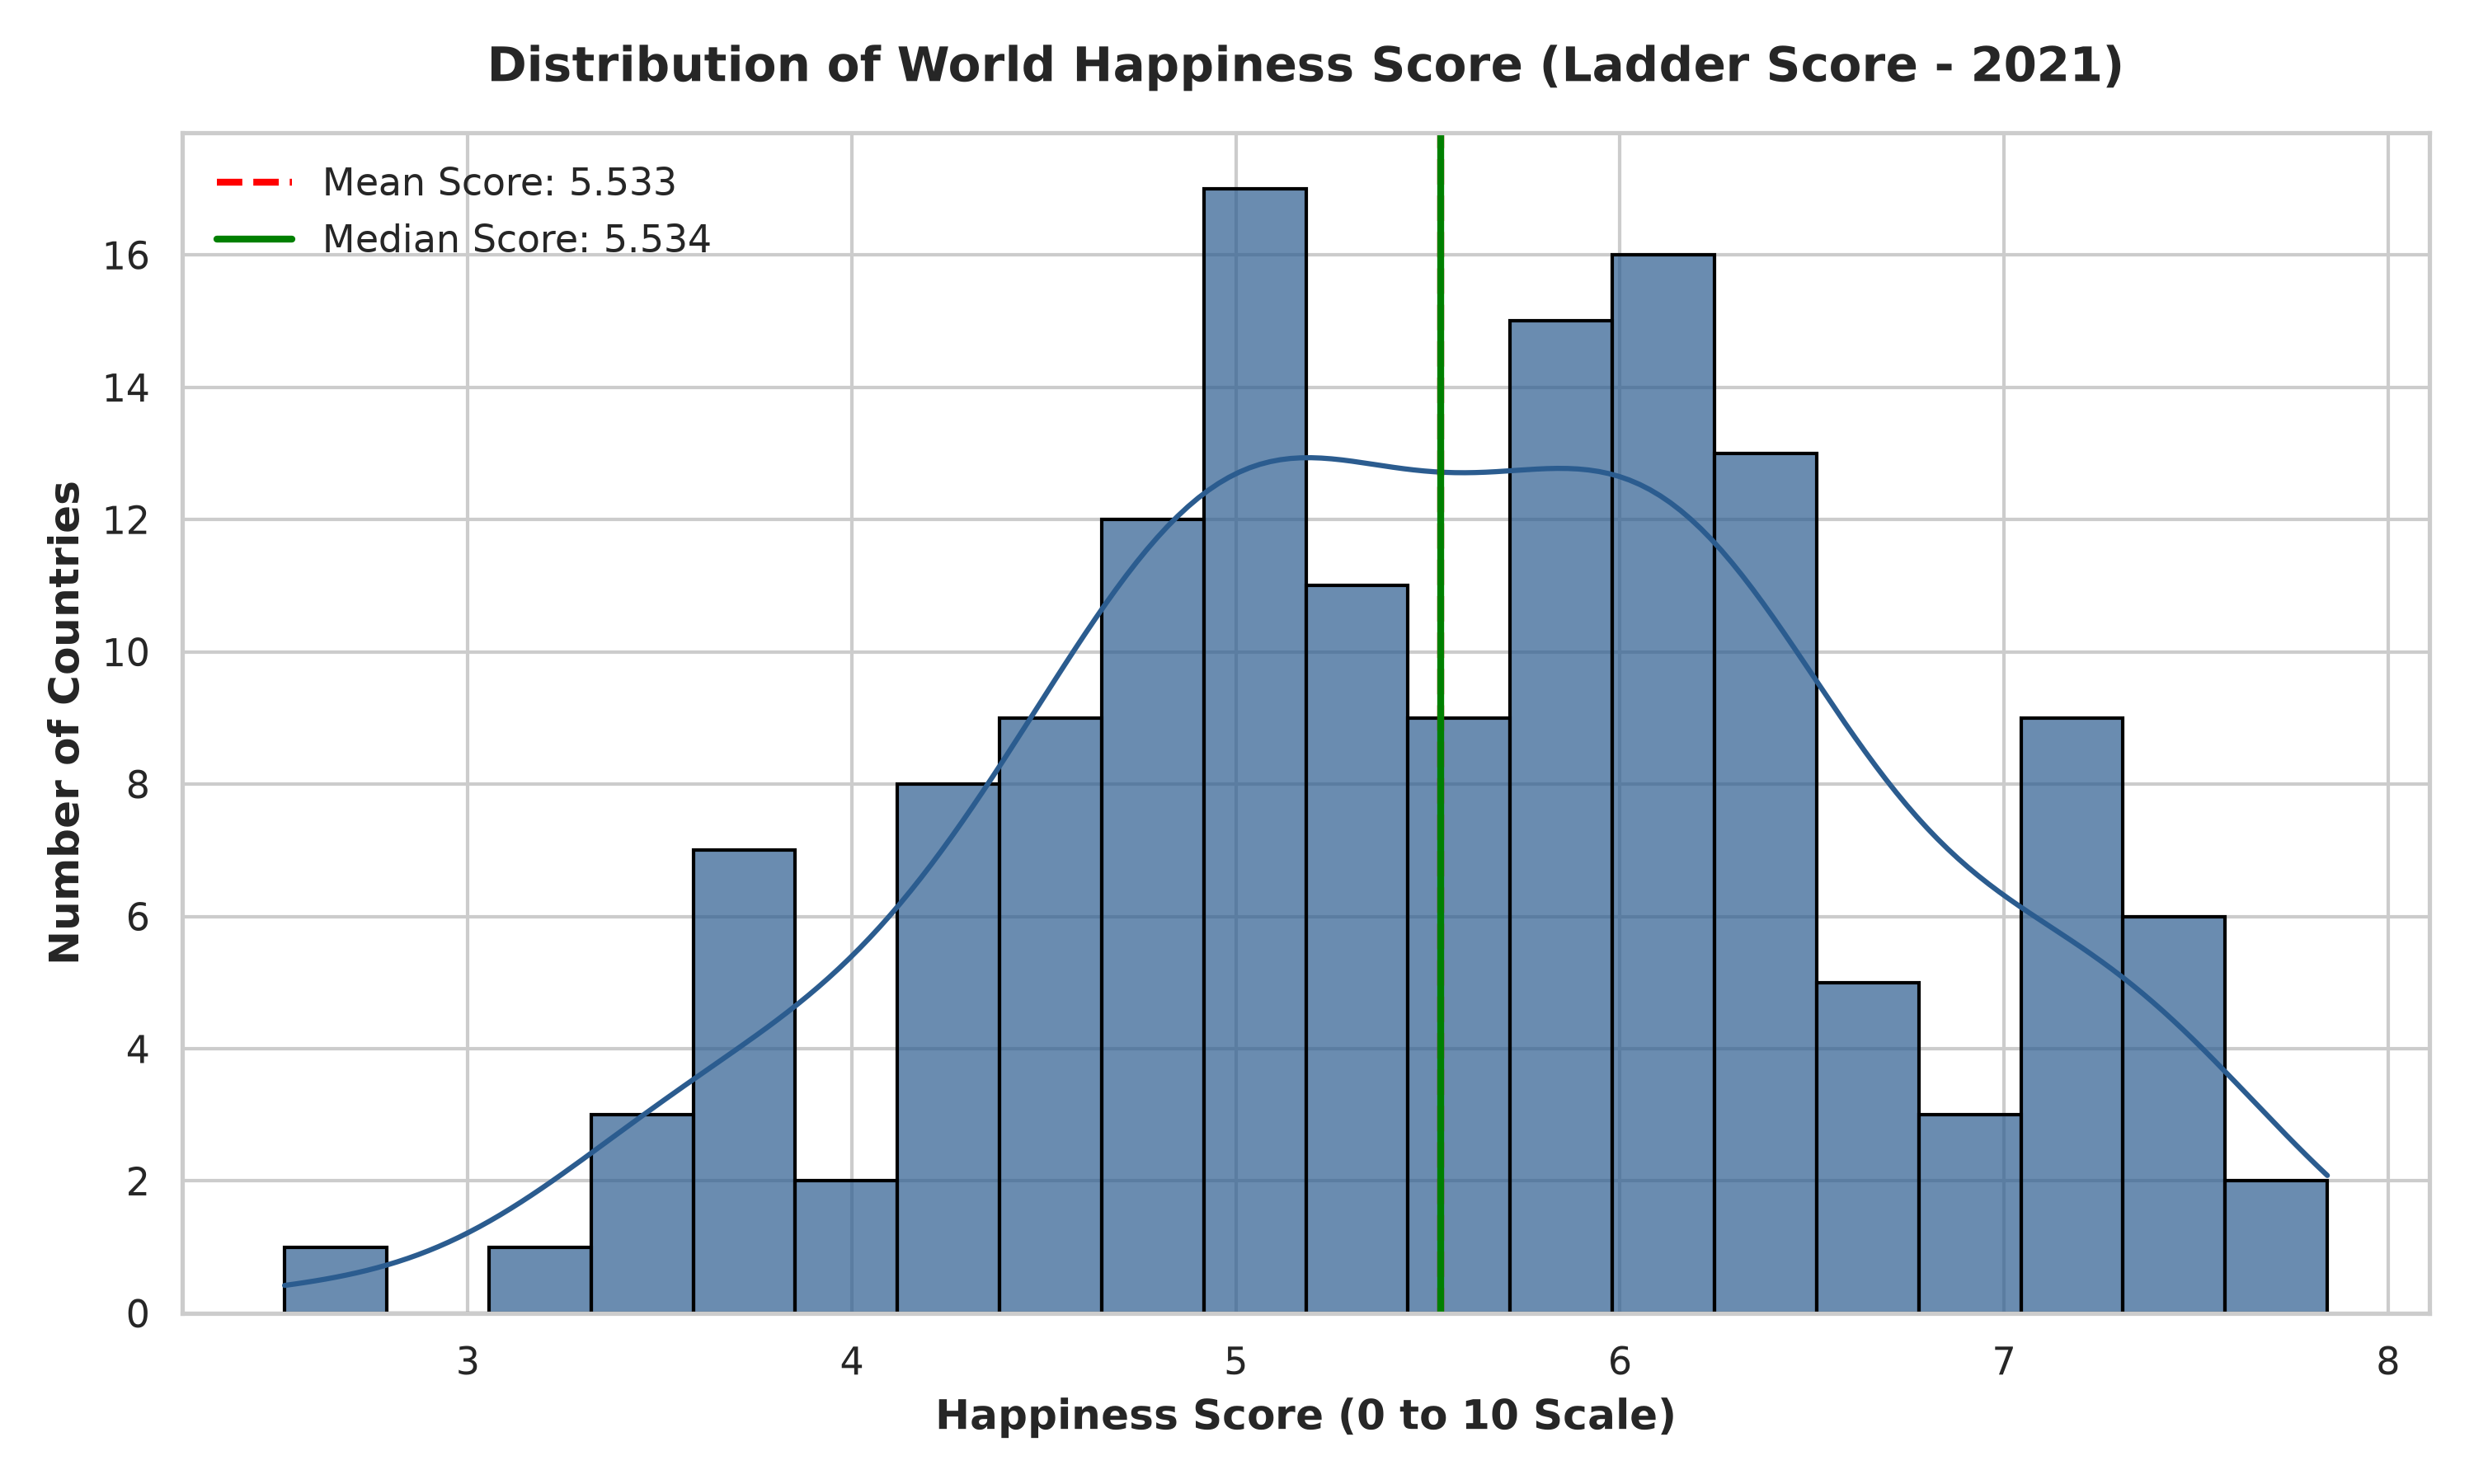

In [6]:
# 1. Happiness Distribution Plot
viz_dir = os.path.join("..", "visualizations")
plot_happiness_distribution(df_clean, viz_dir)

Image(filename=os.path.join(viz_dir, "01_happiness_distribution.png"))


---
### 6. Bivariate & Regional Disparity Analysis

We analyze how Happiness Scores vary across world regions and examine economic output (`LogGDP`) as a primary predictor.


[SAVED] Regional happiness boxplot saved to: ..\visualizations\02_regional_happiness_boxplot.png


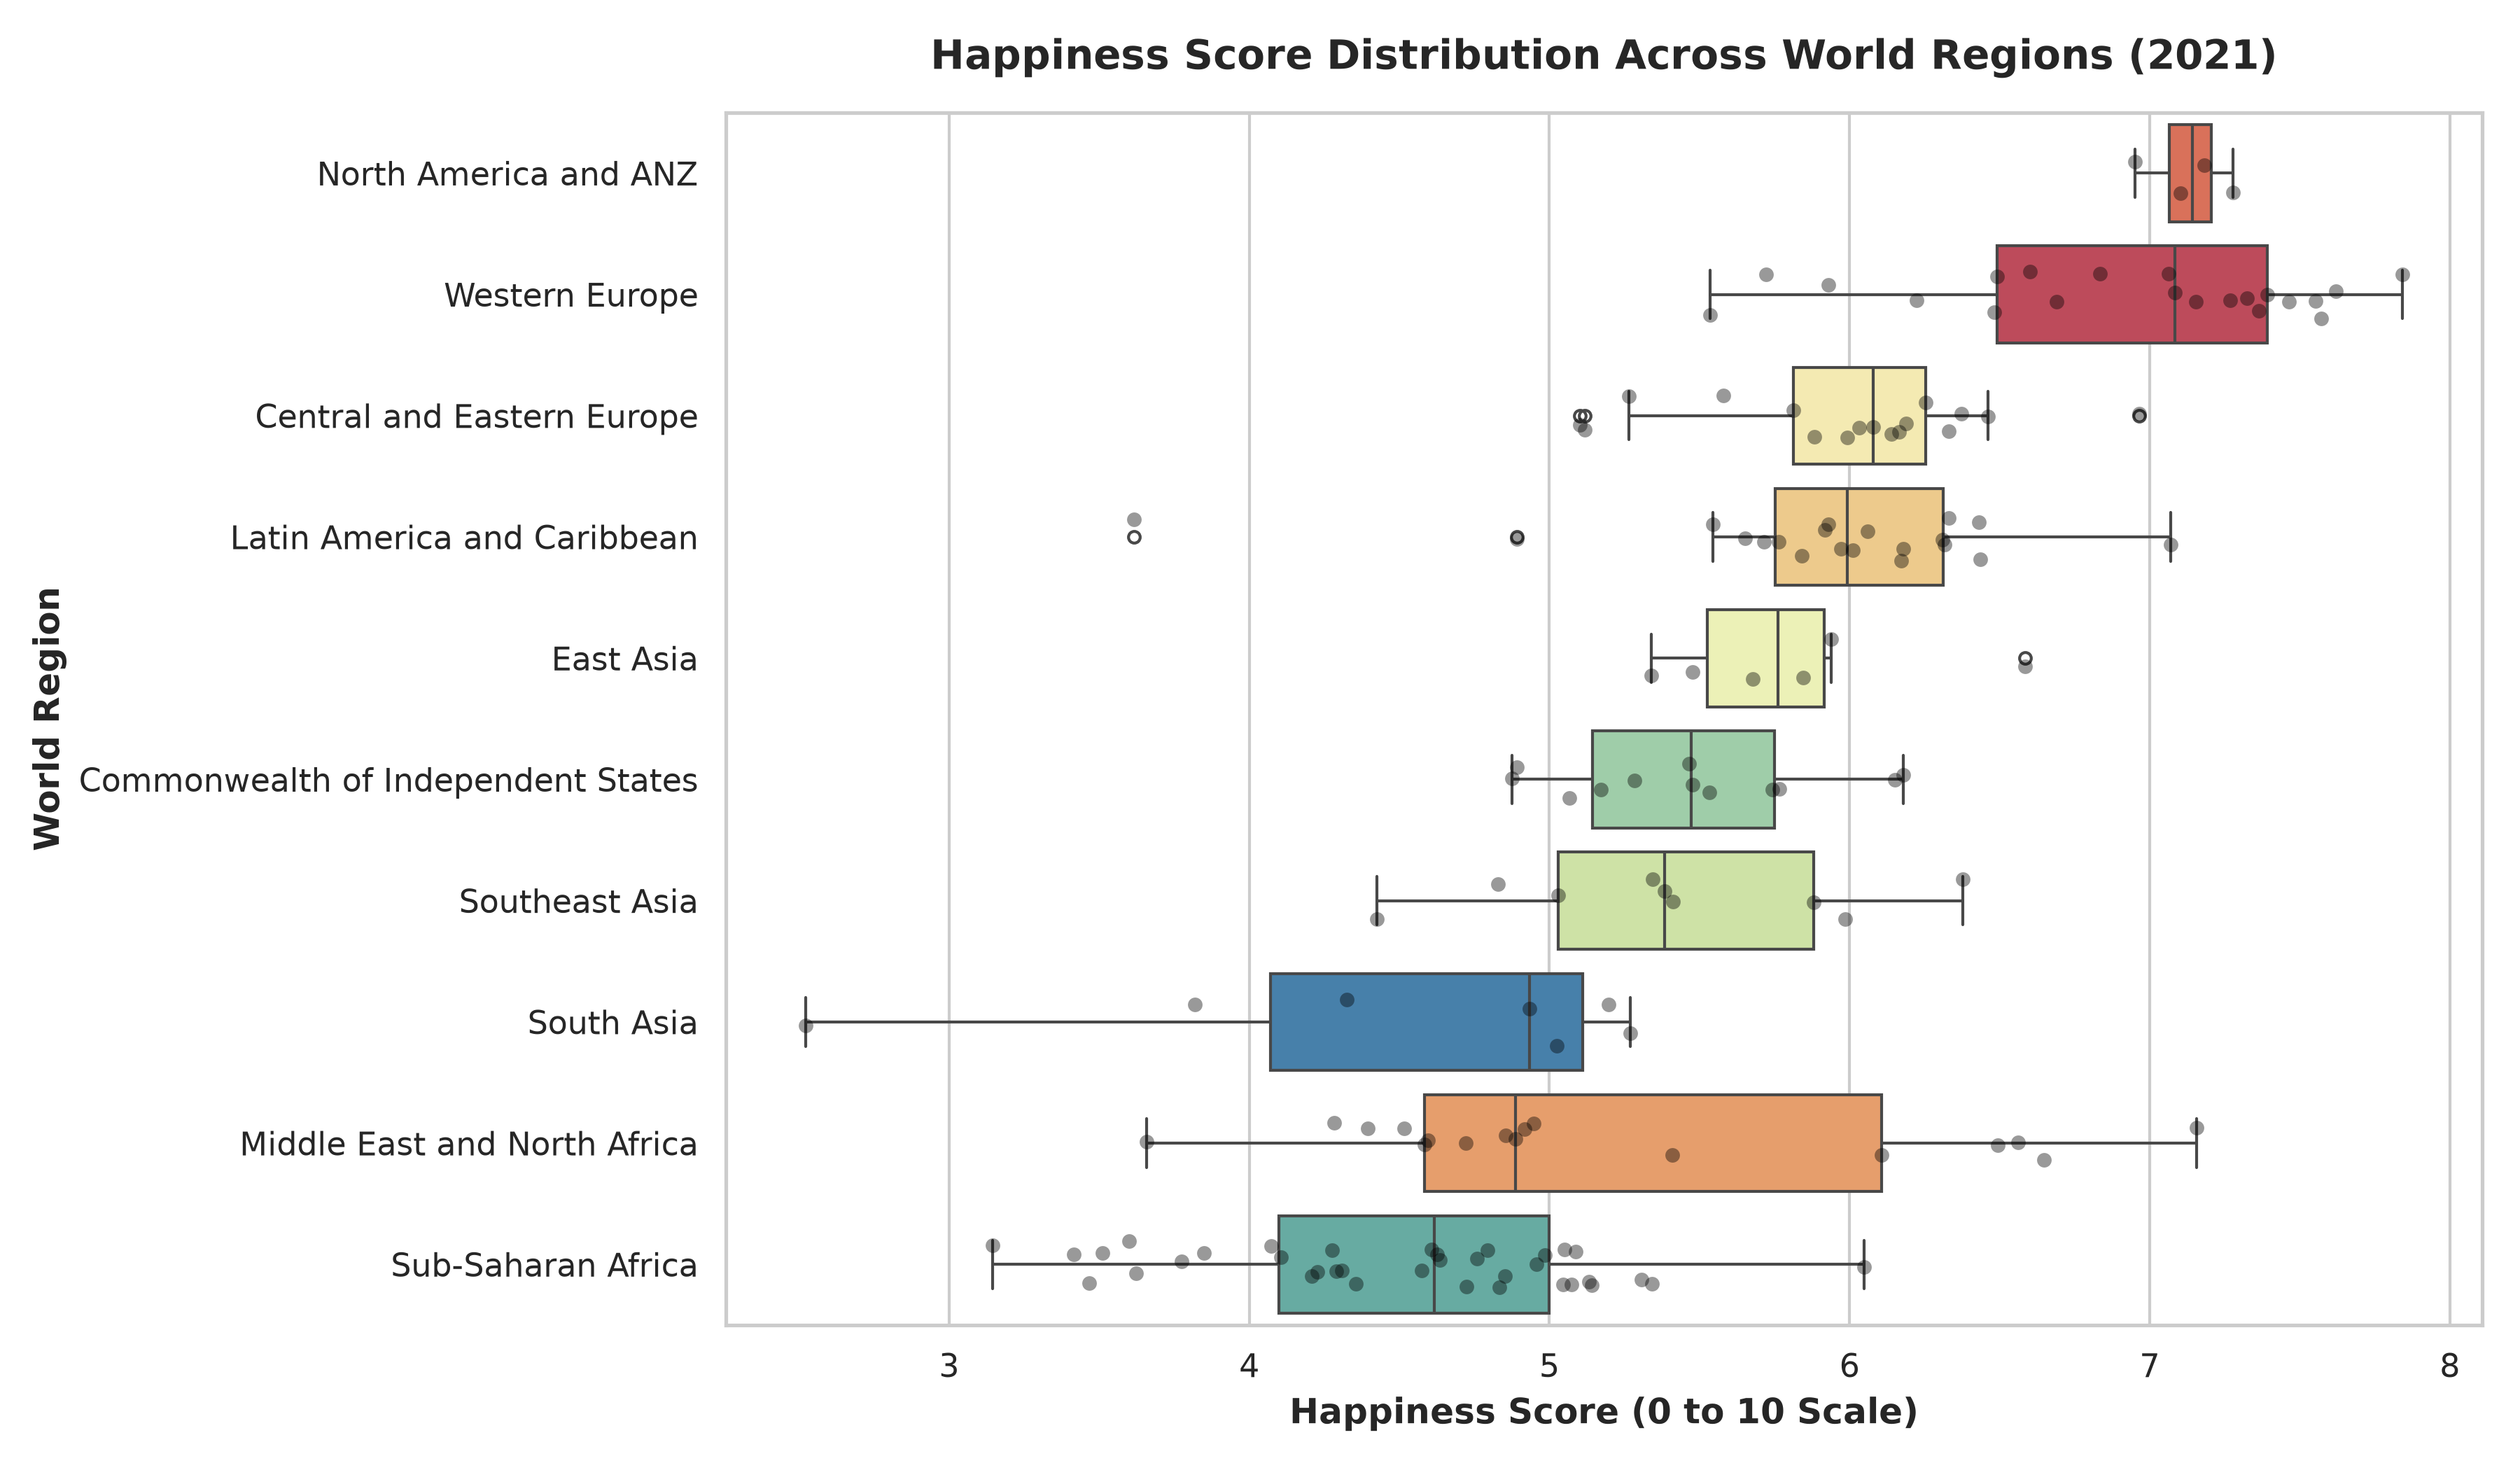

In [7]:
# 2. Regional Happiness Boxplot
plot_regional_boxplot(df_clean, viz_dir)
Image(filename=os.path.join(viz_dir, "02_regional_happiness_boxplot.png"))


[SAVED] GDP vs Happiness scatter plot saved to: ..\visualizations\03_gdp_vs_happiness_scatter.png


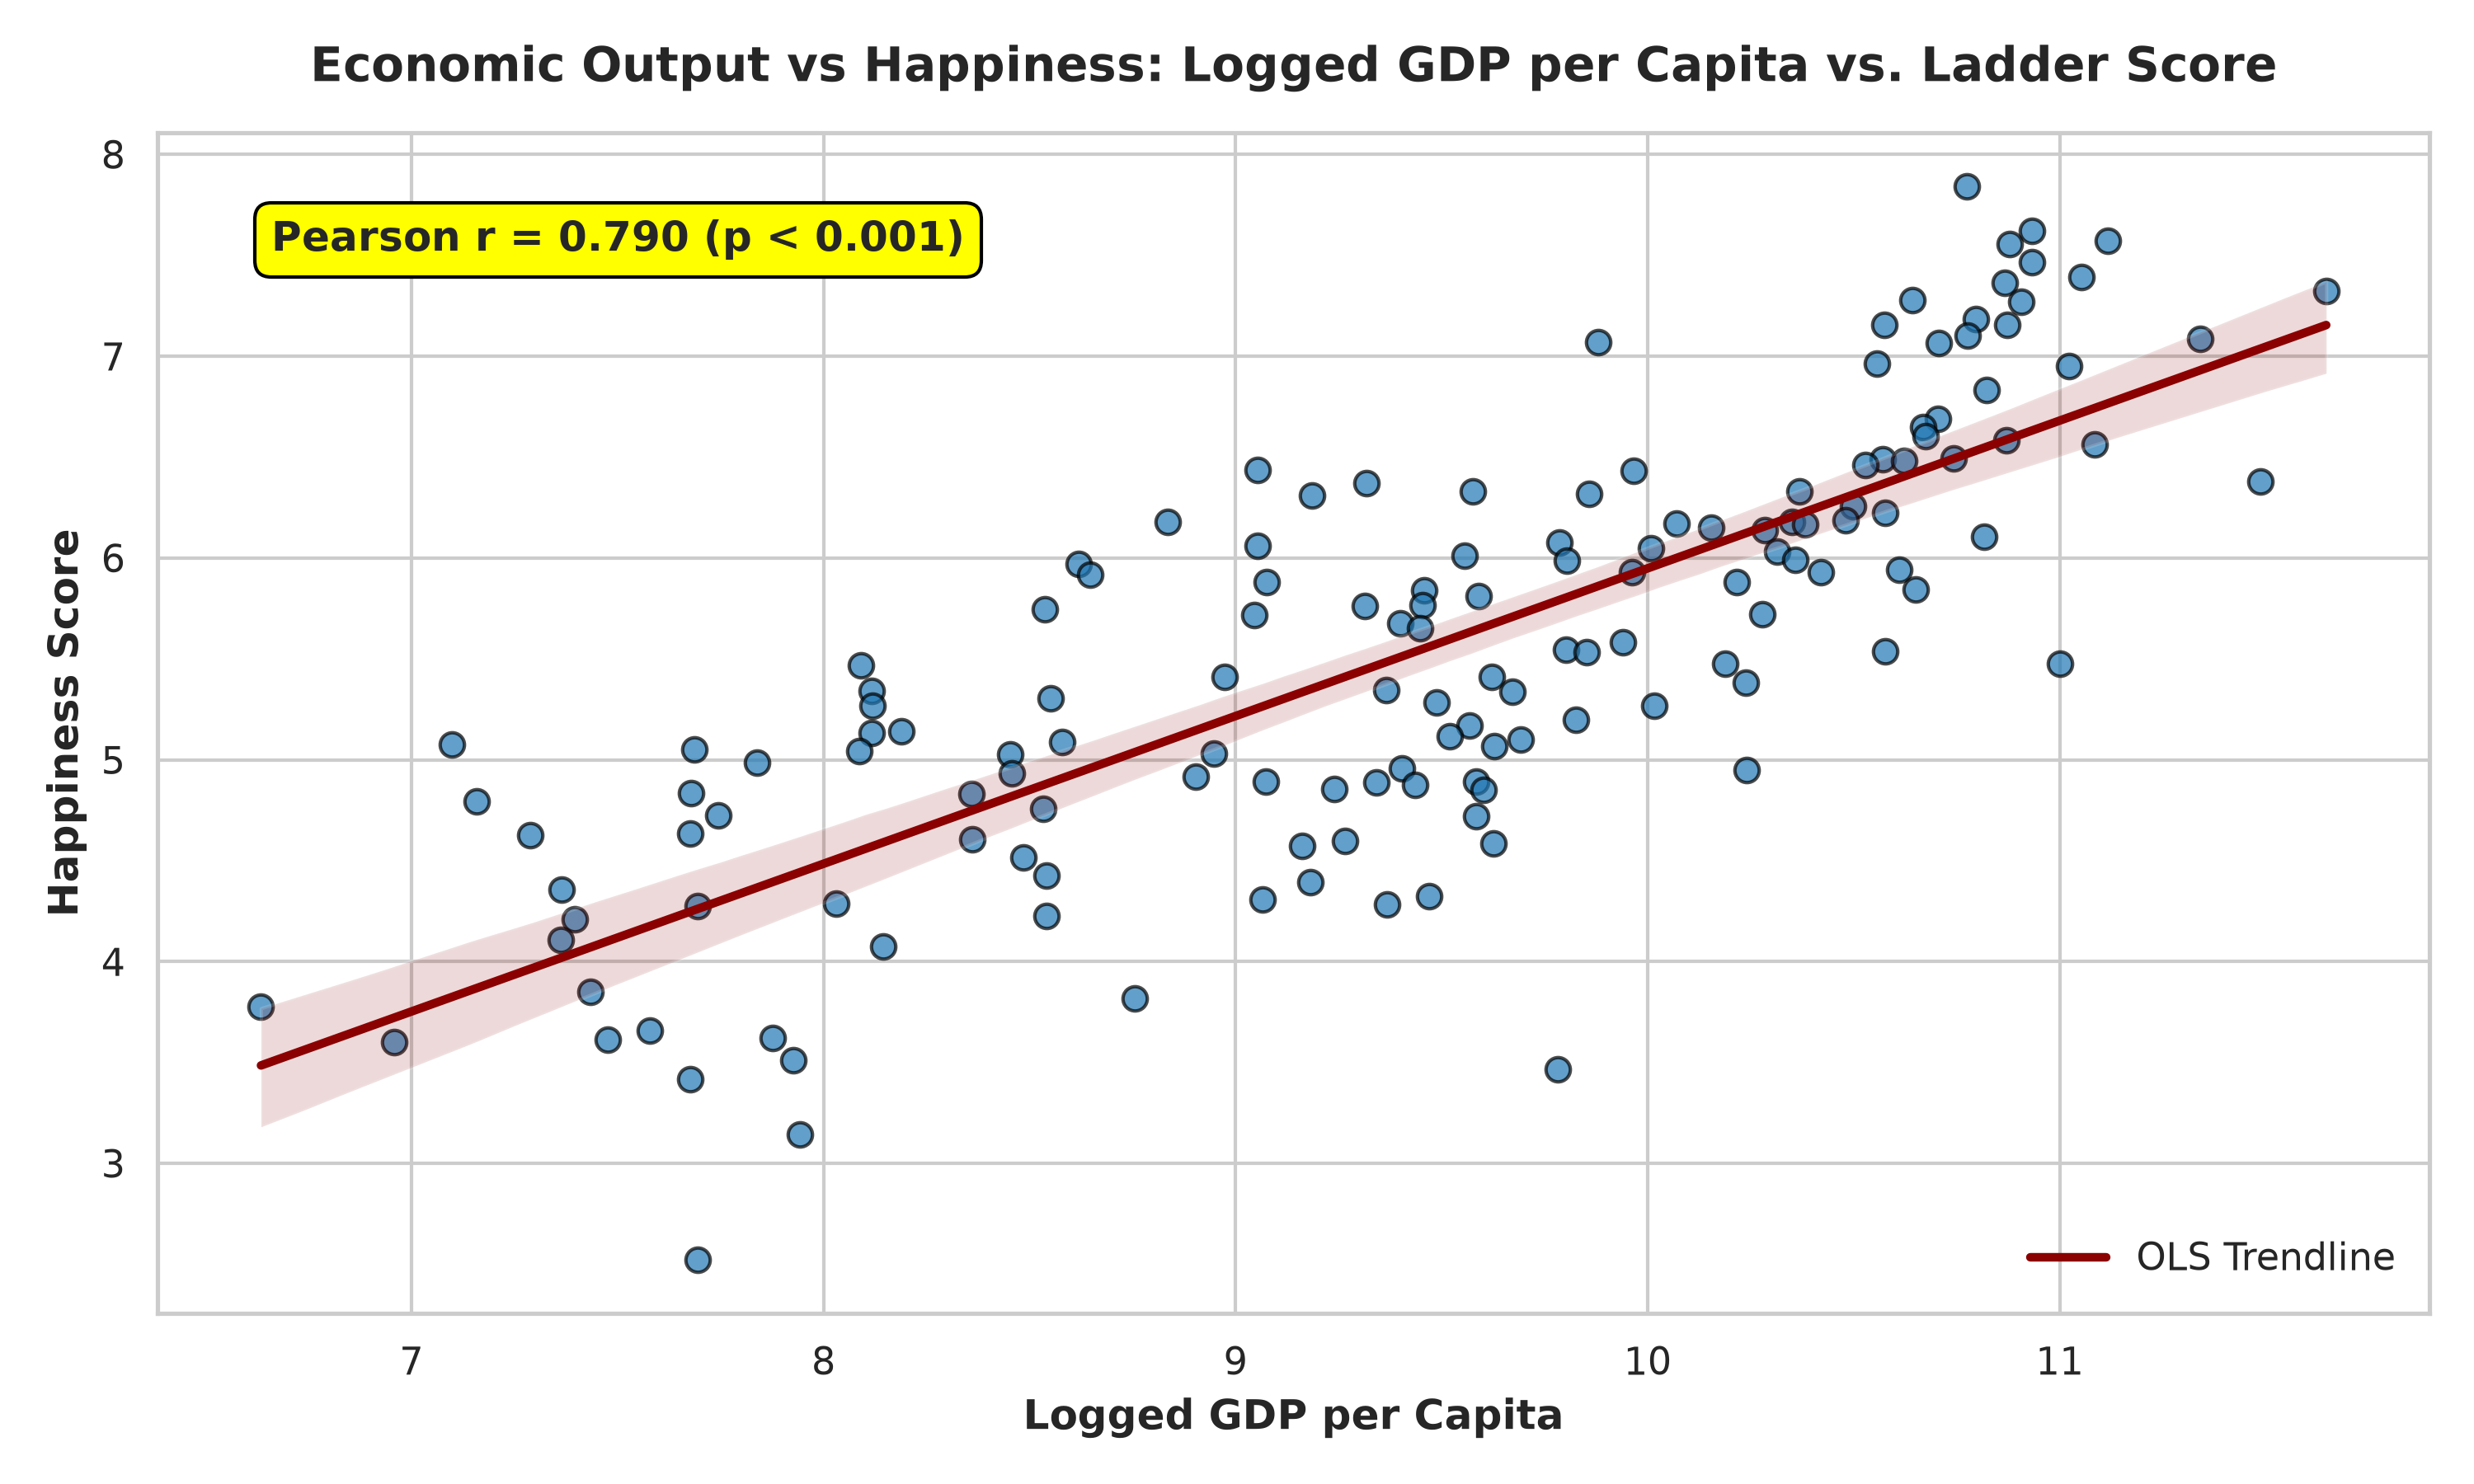

In [8]:
# 3. Logged GDP vs Happiness Scatter Plot with OLS Regression Trendline
plot_gdp_vs_happiness(df_clean, viz_dir)
Image(filename=os.path.join(viz_dir, "03_gdp_vs_happiness_scatter.png"))


[SAVED] Top/Bottom 10 countries bar chart saved to: ..\visualizations\05_top_bottom_countries_bar.png


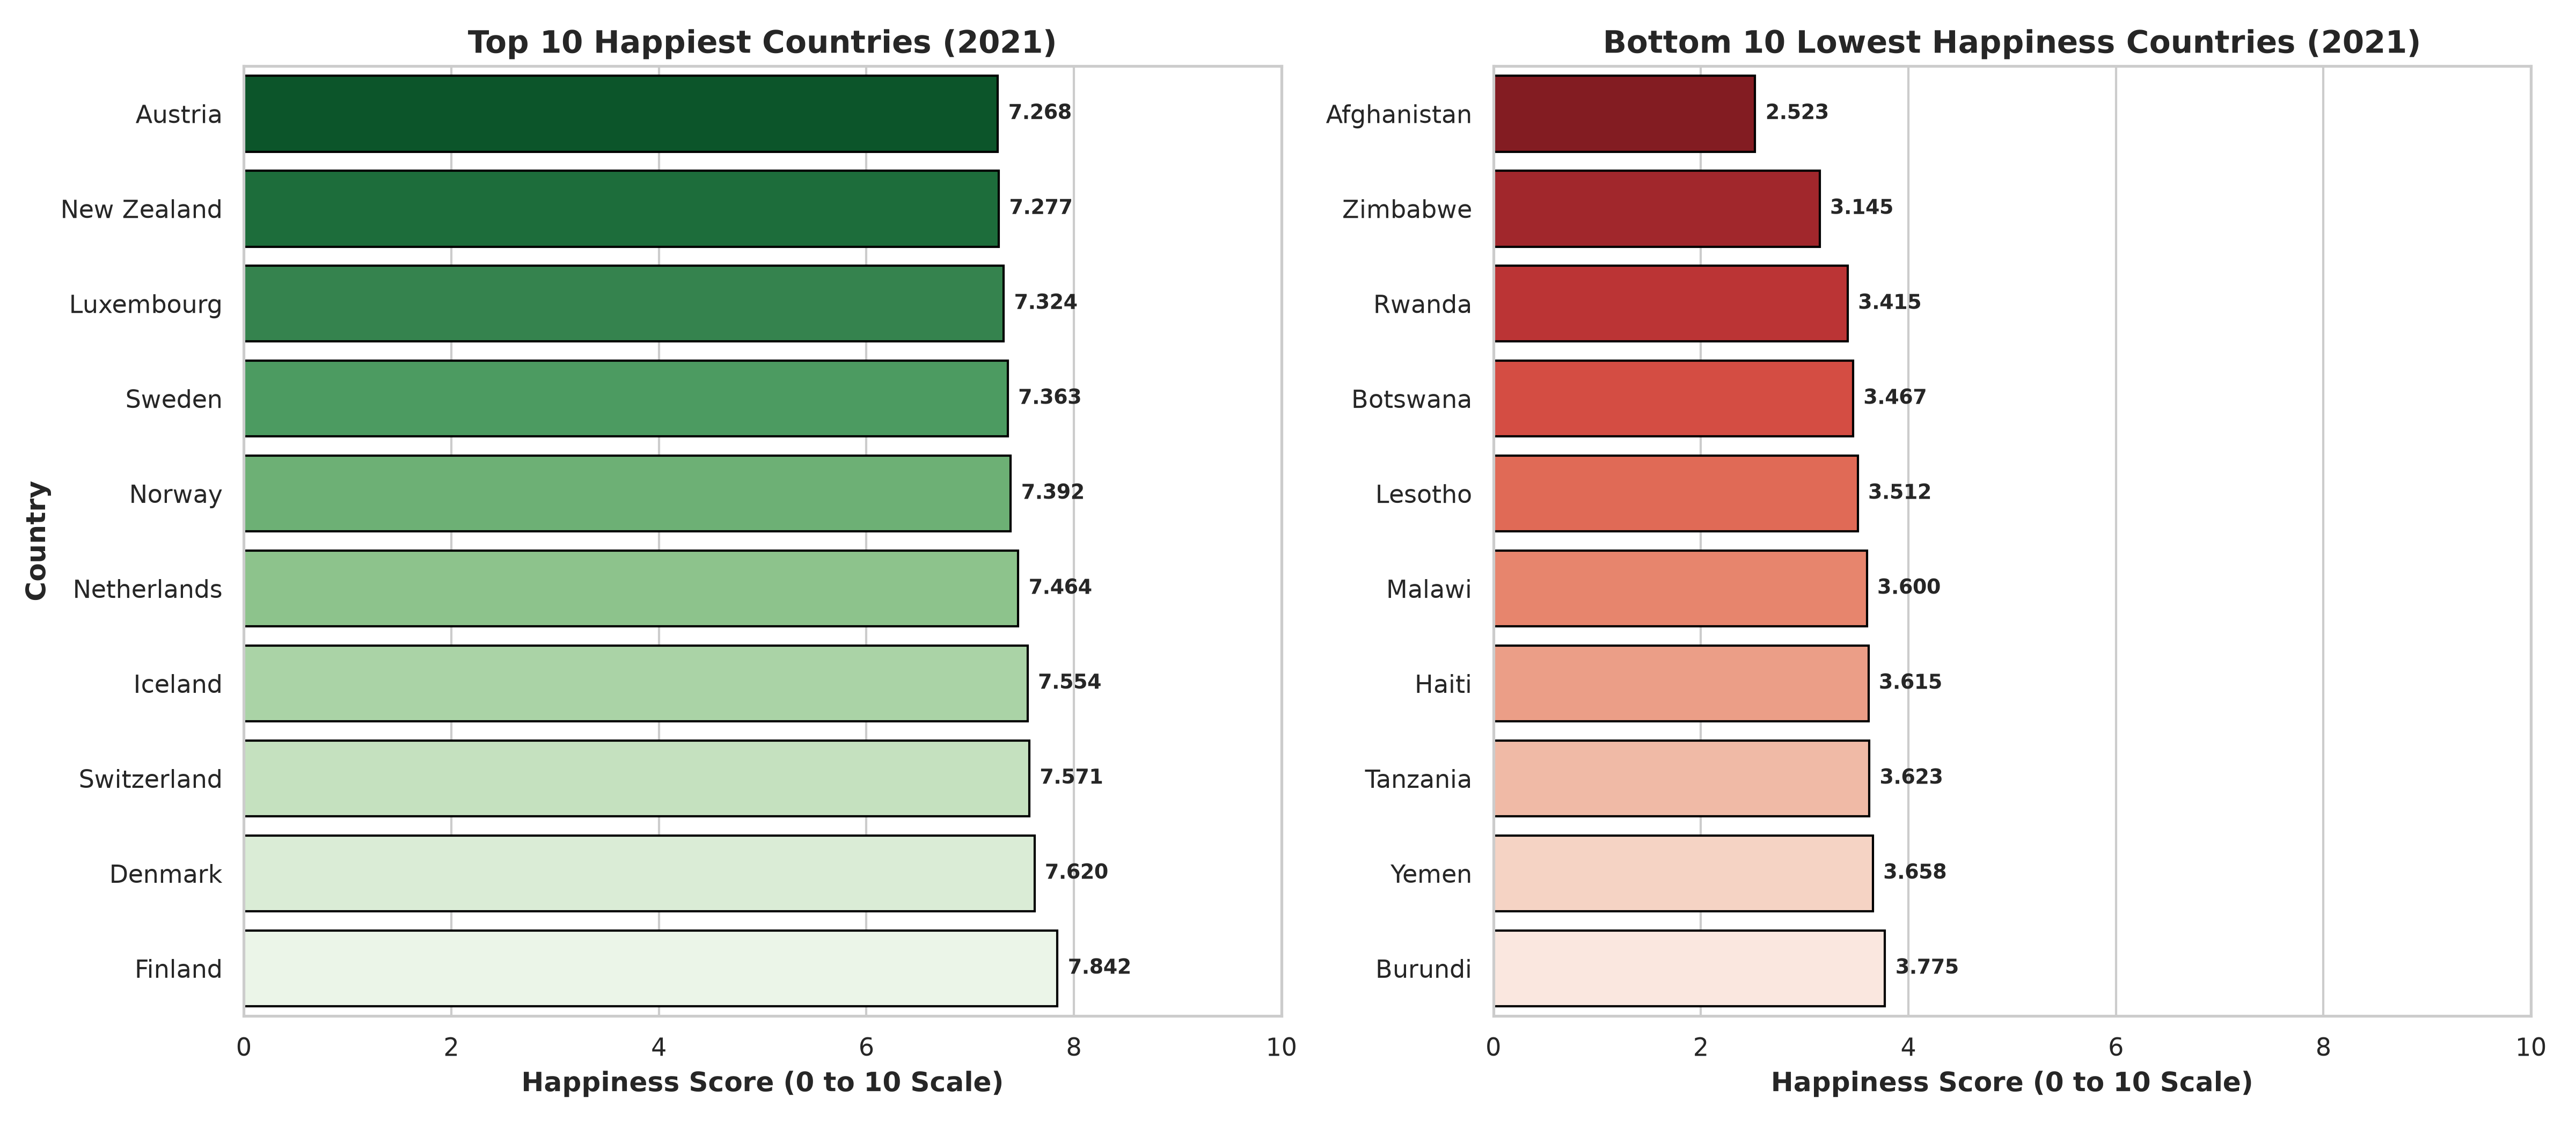

In [9]:
# 4. Top 10 vs Bottom 10 Countries
plot_top10_bottom10_countries(df_clean, viz_dir)
Image(filename=os.path.join(viz_dir, "05_top_bottom_countries_bar.png"))


[SAVED] Regional mean happiness plot saved to: ..\visualizations\06_regional_mean_happiness.png


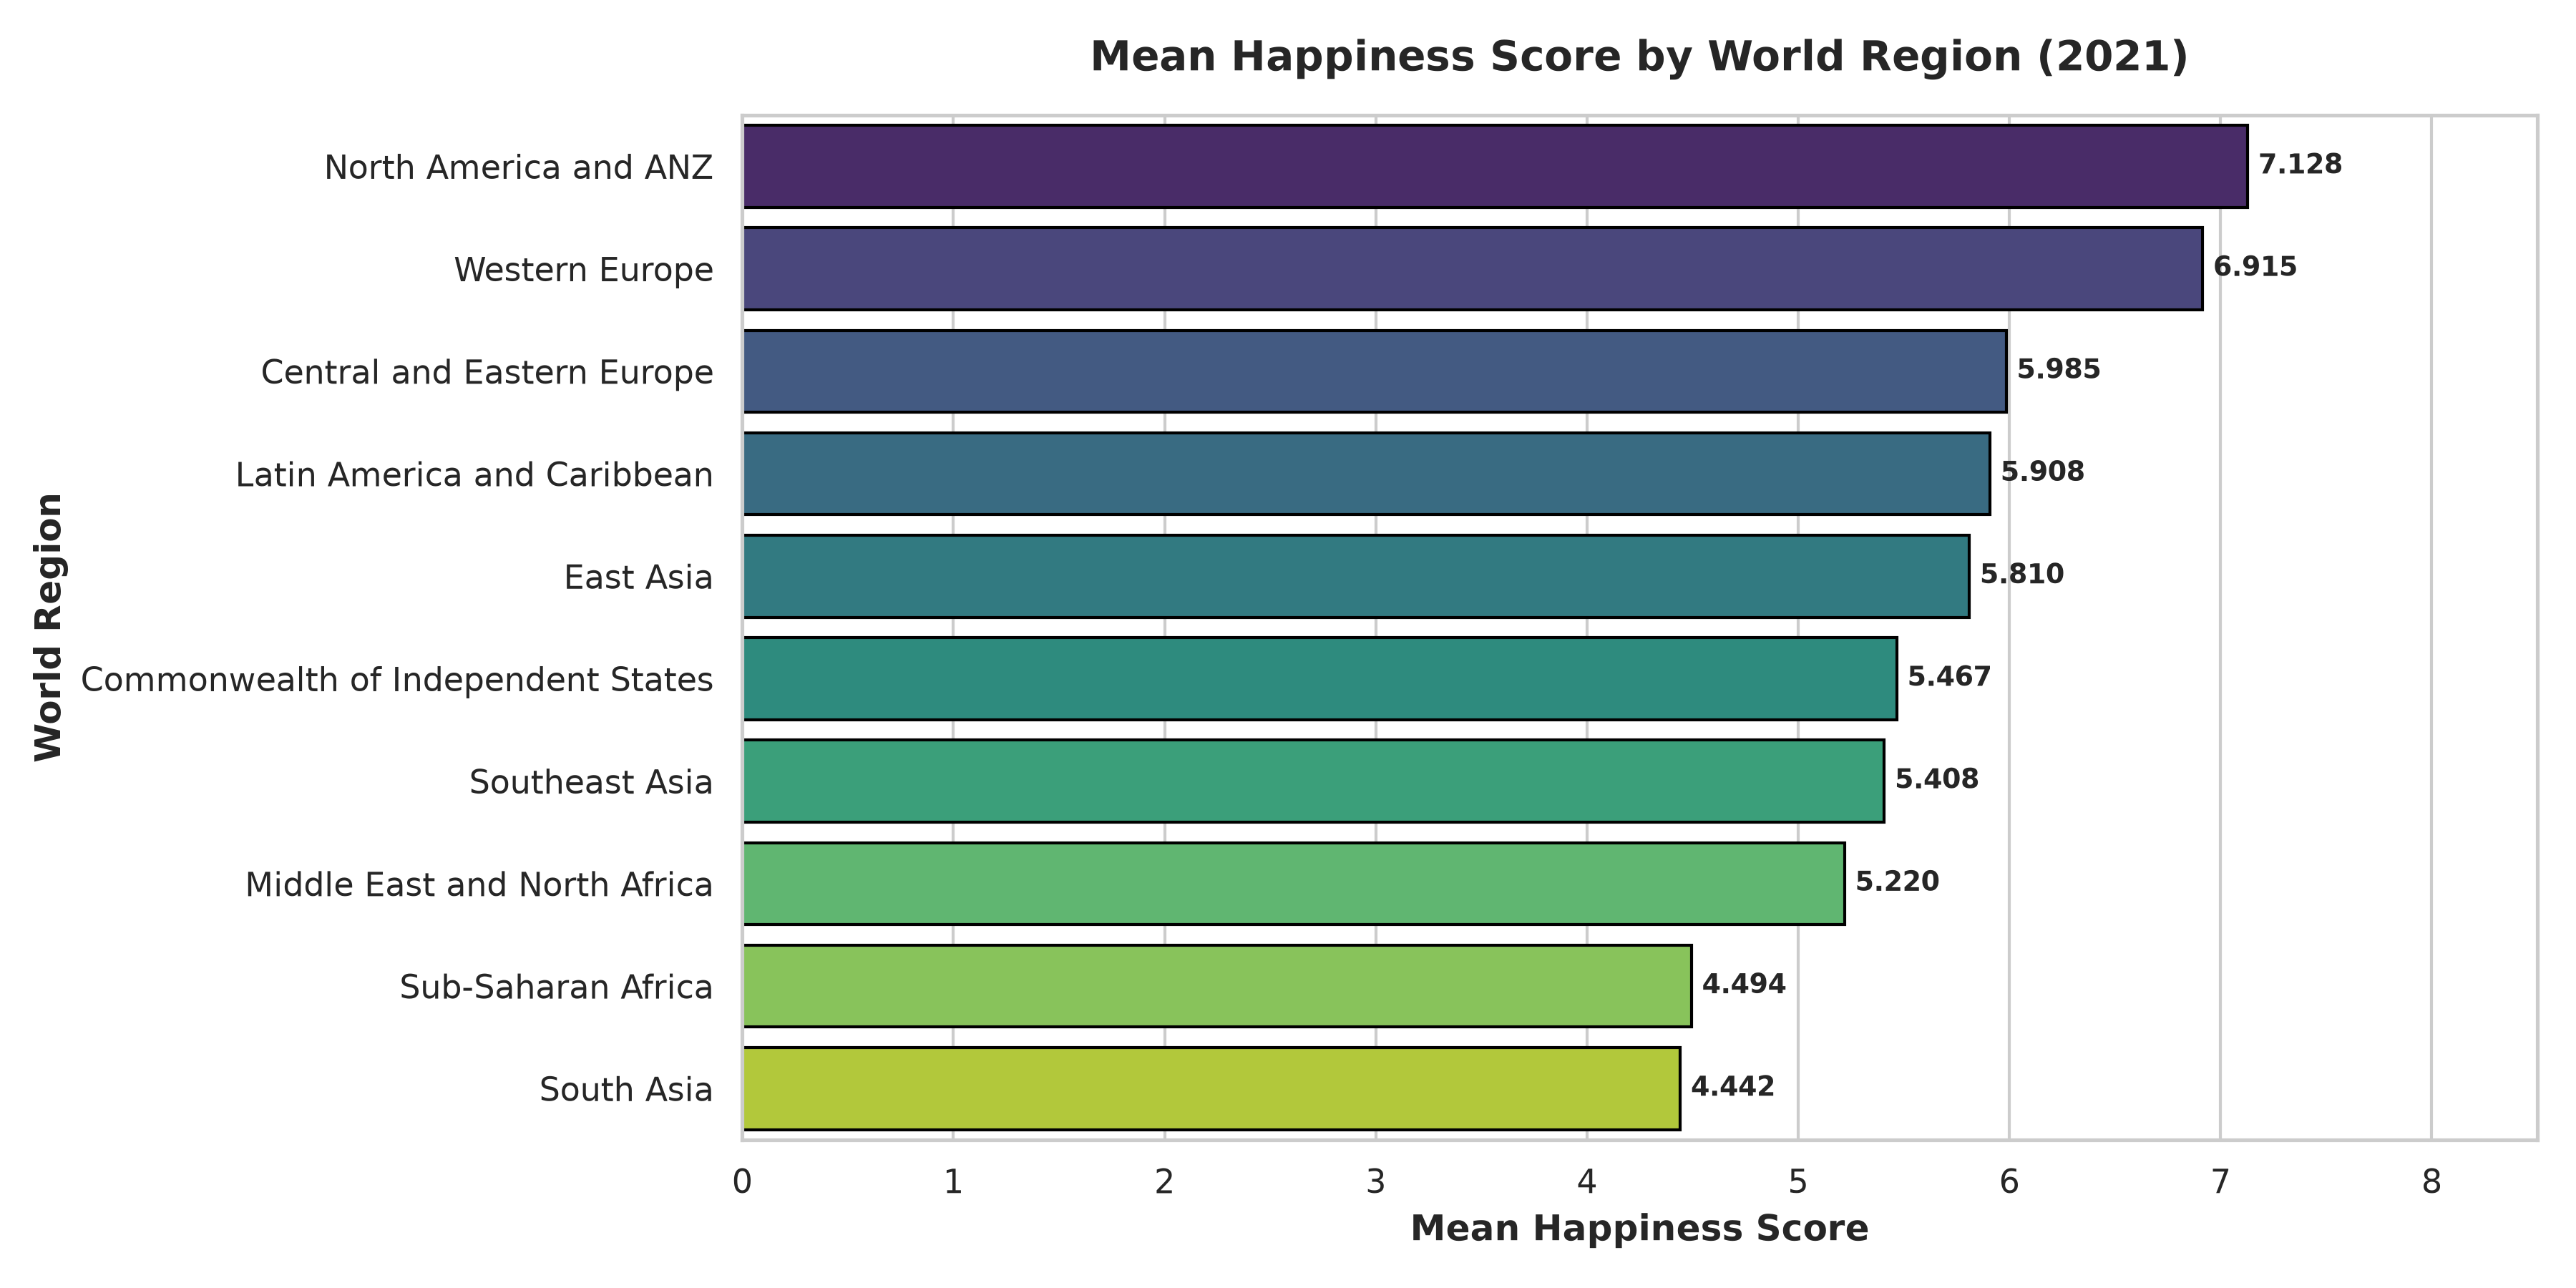

In [10]:
# 5. Regional Mean Happiness Comparison
plot_regional_mean_happiness(df_clean, viz_dir)
Image(filename=os.path.join(viz_dir, "06_regional_mean_happiness.png"))


---
### 7. Multivariate Correlation Analysis
We compute Pearson ($r$, linear relationship) and Spearman ($ho$, monotonic rank relationship) correlation matrices.


In [11]:
pearson_corr, spearman_corr = compute_correlations(df_clean)

print("=== PEARSON CORRELATION MATRIX ===")
display(pearson_corr)


=== PEARSON CORRELATION MATRIX ===


,HappinessScore,LogGDP,SocialSupport,HealthyLifeExpectancy,Freedom,Generosity,CorruptionPerception
HappinessScore,1.0000,0.7898,0.7569,0.7681,0.6078,-0.0178,-0.4211
LogGDP,0.7898,1.0000,0.7853,0.8595,0.4323,-0.1993,-0.3423
SocialSupport,0.7569,0.7853,1.0000,0.7233,0.4829,-0.1149,-0.2032
HealthyLifeExpectancy,0.7681,0.8595,0.7233,1.0000,0.4615,-0.1618,-0.3644
Freedom,0.6078,0.4323,0.4829,0.4615,1.0000,0.1694,-0.4014
Generosity,-0.0178,-0.1993,-0.1149,-0.1618,0.1694,1.0000,-0.1640
CorruptionPerception,-0.4211,-0.3423,-0.2032,-0.3644,-0.4014,-0.1640,1.0000


[SAVED] Correlation heatmap saved to: ..\visualizations\04_correlation_heatmap.png


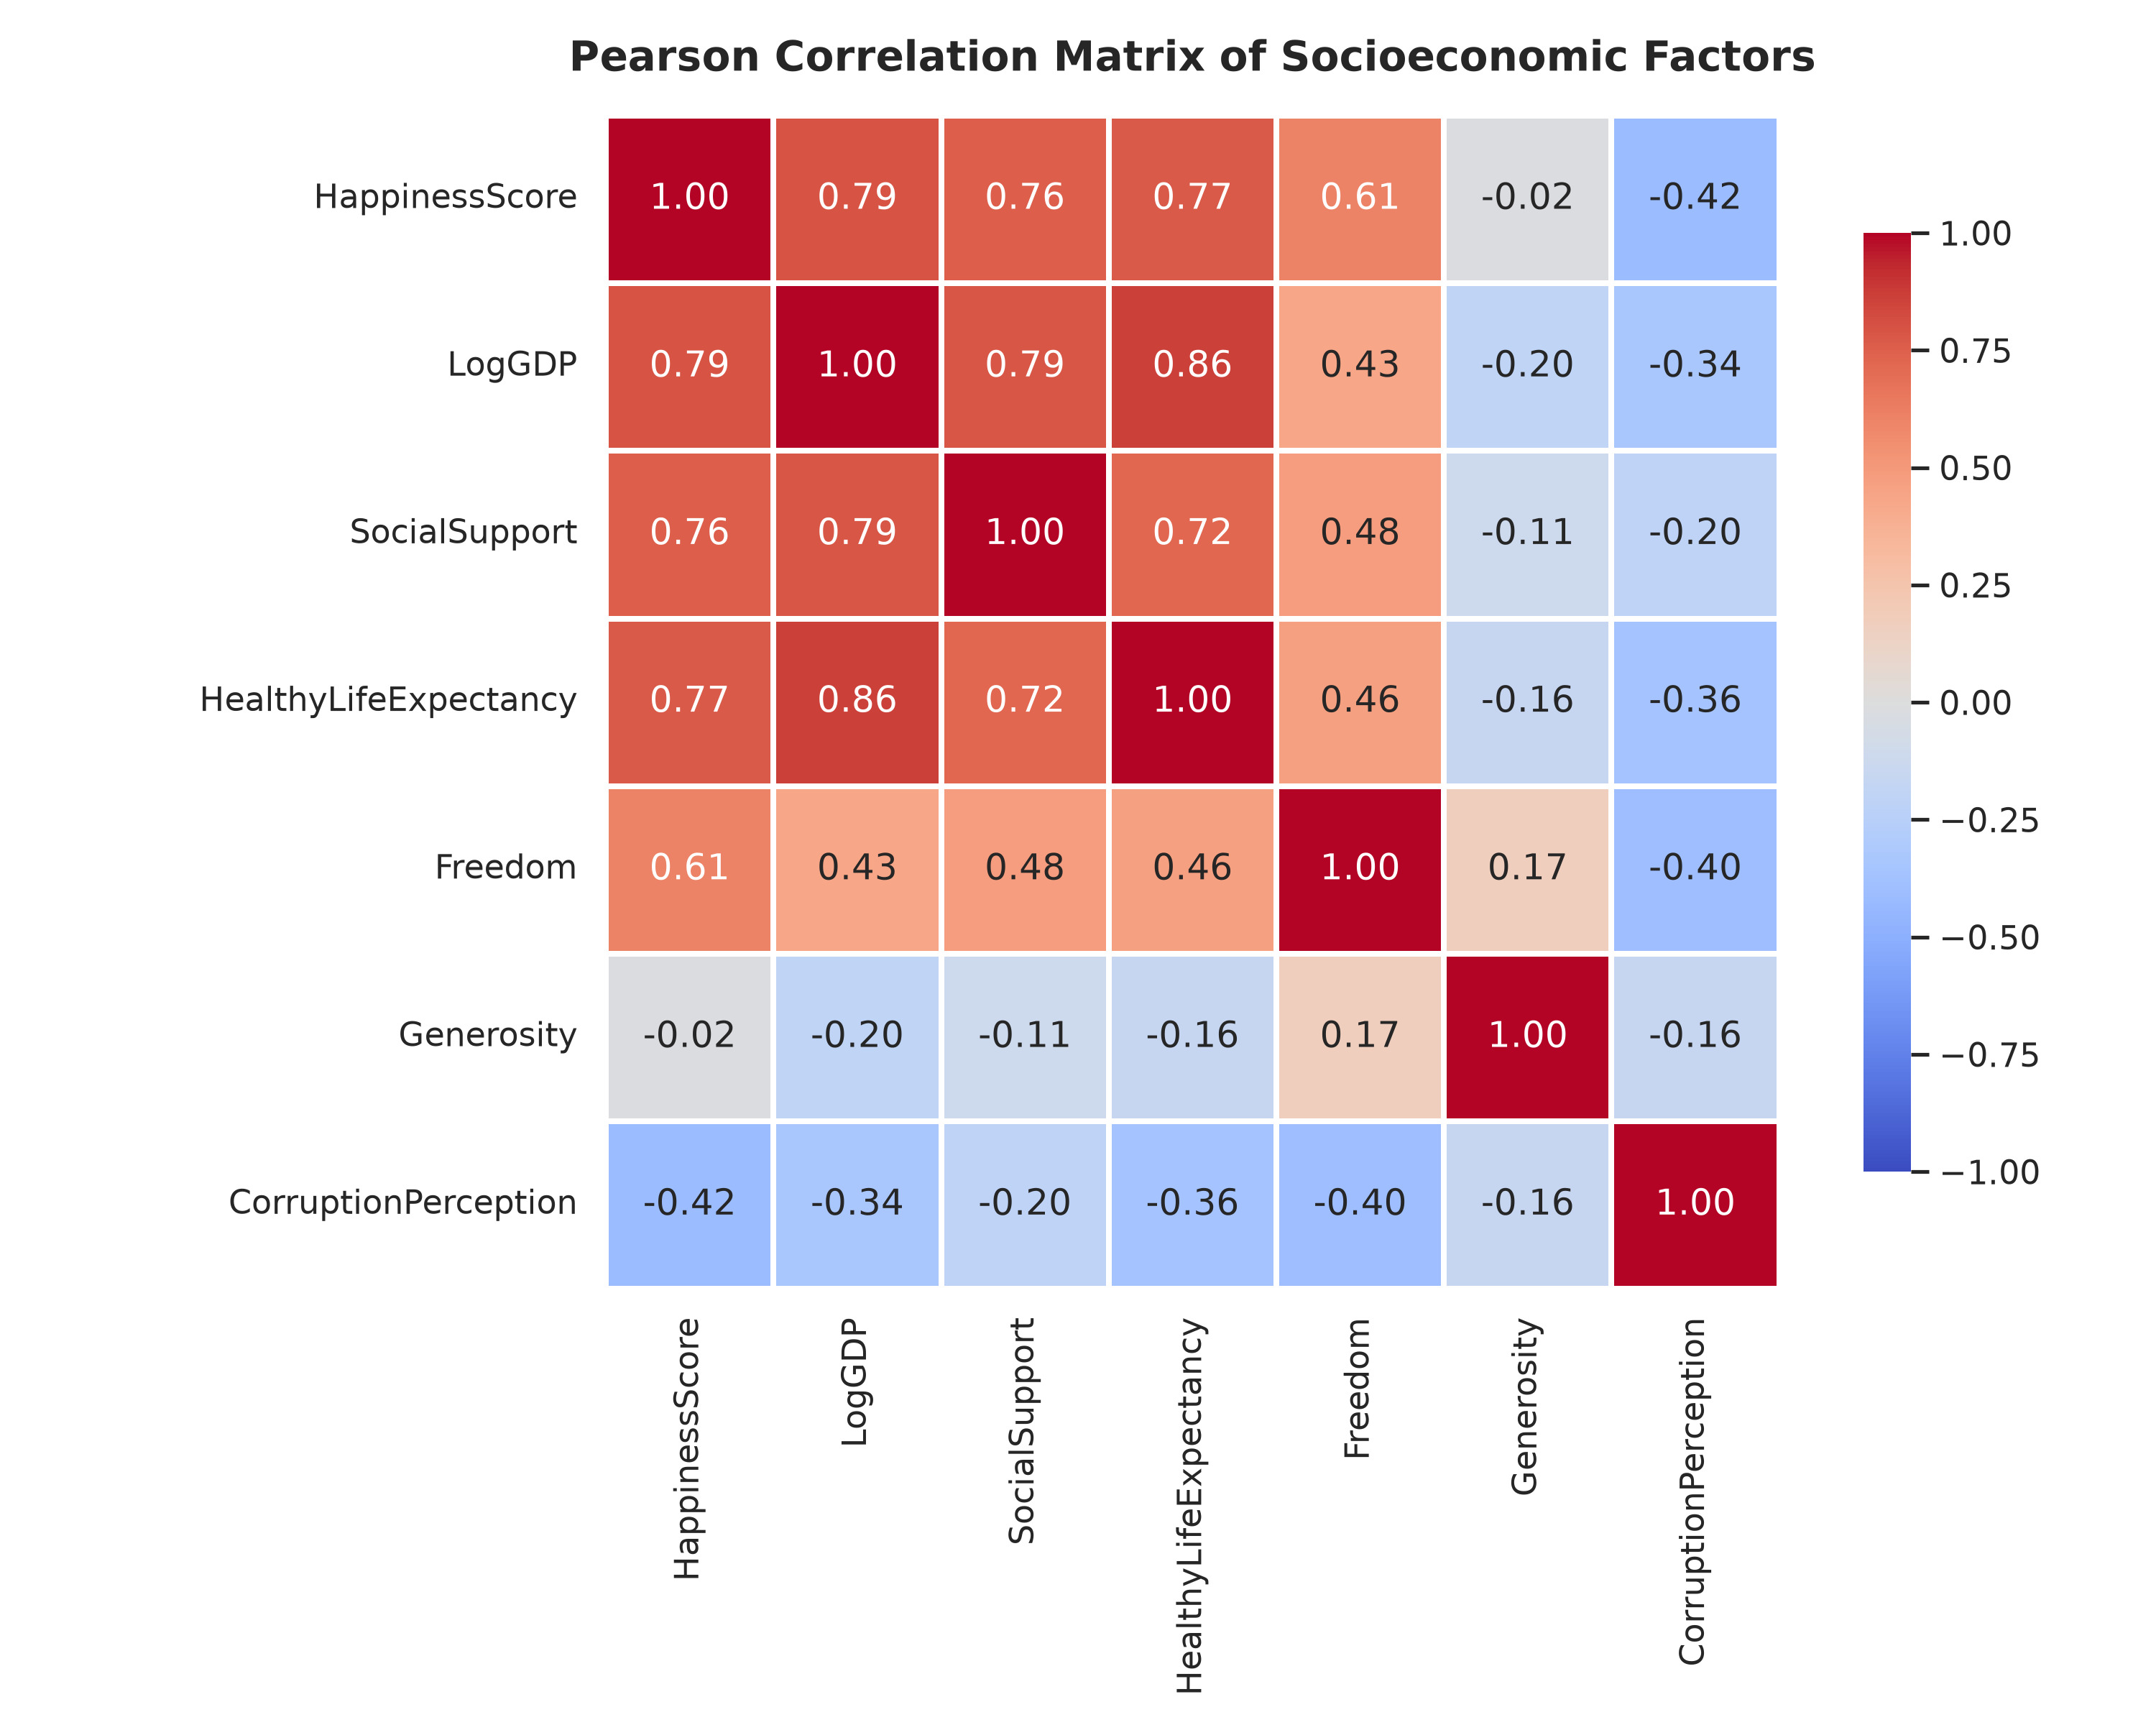

In [12]:
# 6. Correlation Heatmap
plot_correlation_heatmap(df_clean, viz_dir)
Image(filename=os.path.join(viz_dir, "04_correlation_heatmap.png"))


[SAVED] Pairwise factors scatter grid saved to: ..\visualizations\07_pairwise_factors_scatter.png


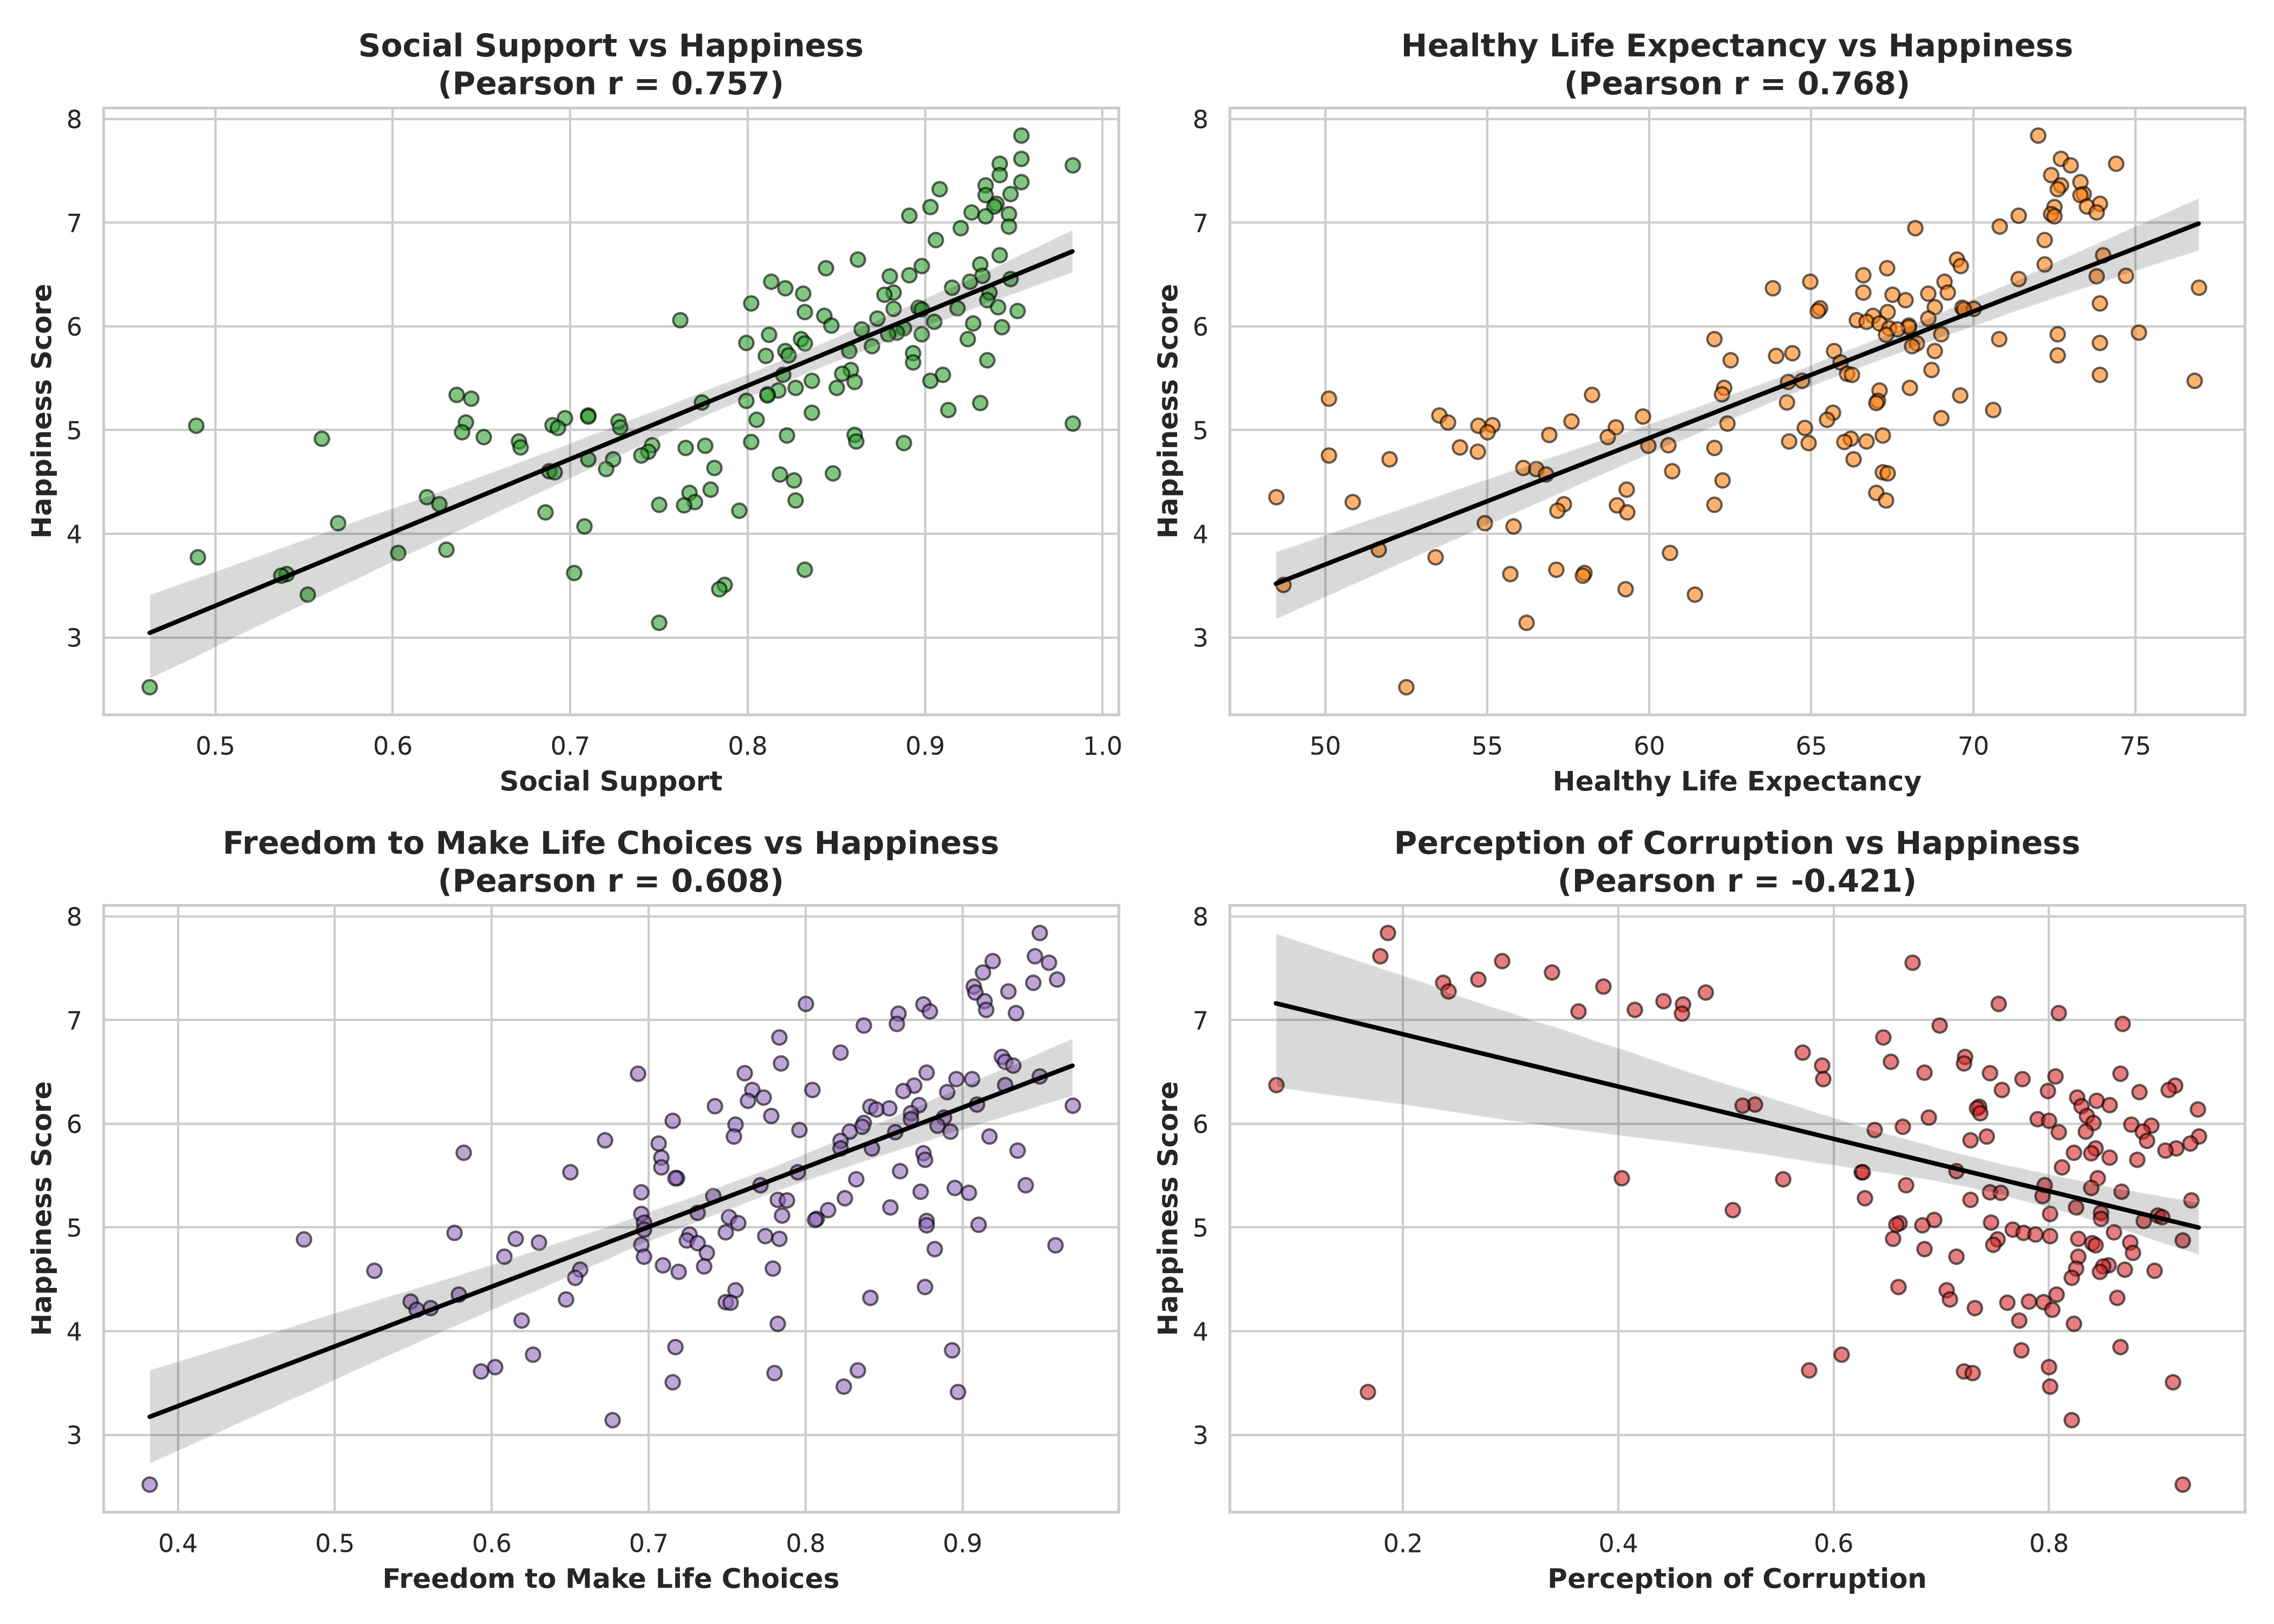

In [13]:
# 7. Pairwise Factors Scatter Grid
plot_key_drivers_scatter_grid(df_clean, viz_dir)
Image(filename=os.path.join(viz_dir, "07_pairwise_factors_scatter.png"))


[SAVED] Correlation comparison chart saved to: ..\visualizations\08_correlation_comparison.png


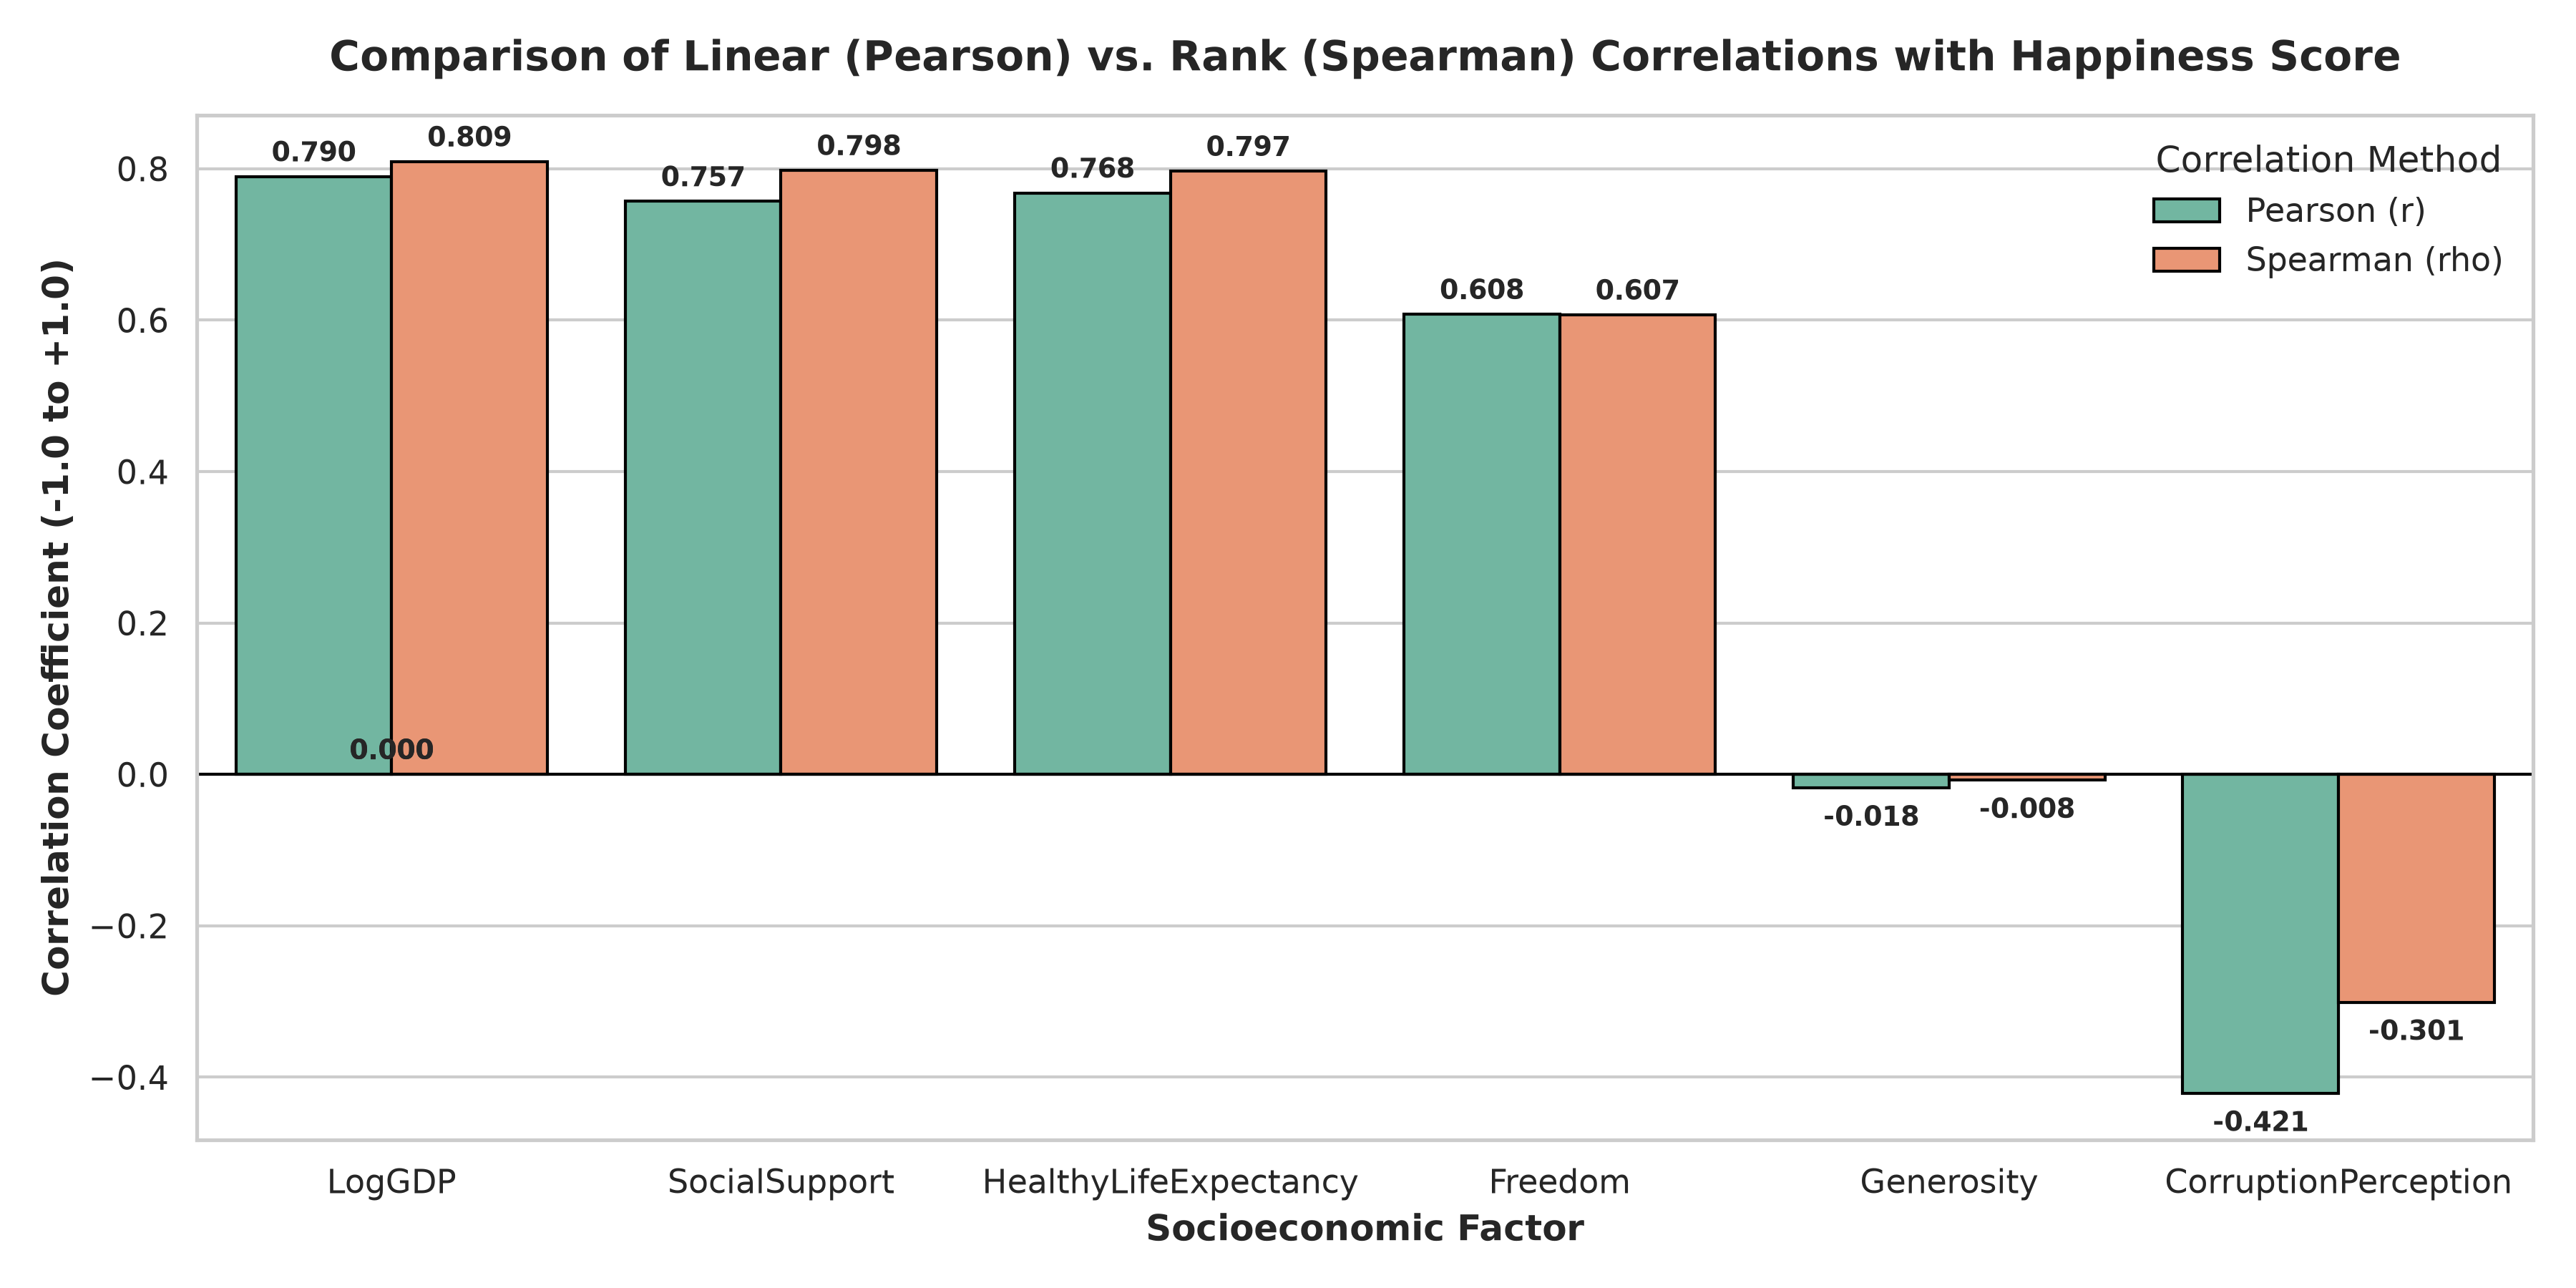

In [14]:
# 8. Pearson vs Spearman Correlation Comparison Chart
plot_correlation_comparison(df_clean, viz_dir)
Image(filename=os.path.join(viz_dir, "08_correlation_comparison.png"))


---
### 8. Key Empirical Findings & Discussion

1. **Top & Bottom Rankings**:
   - **Happiest Country**: **Finland (7.842)** (followed by Denmark, Switzerland, Iceland, Netherlands).
   - **Unhappiest Country**: **Afghanistan (2.523)** (followed by Zimbabwe, Rwanda, Botswana, Malawi).
   - **Highest Ranked Region**: **North America and ANZ (7.128)** & **Western Europe (6.915)**.
   - **Lowest Ranked Region**: **South Asia (4.442)** & **Sub-Saharan Africa (4.494)**.

2. **Primary Predictors**:
   - **Logged GDP per Capita**: Highest correlation ($r = +0.7898$, $ho = +0.8131$). Economic prosperity provides essential healthcare, security, and infrastructure.
   - **Healthy Life Expectancy**: Strongly correlated ($r = +0.7681$).
   - **Social Support**: Strongly correlated ($r = +0.7569$). Having trusted friends/family in times of need is vital.
   - **Freedom to Make Life Choices**: Moderately correlated ($r = +0.6078$).
   - **Perception of Corruption**: Negatively correlated ($r = -0.4211$). High institutional corruption reduces public well-being.

3. **Methodological Note on Correlation vs. Causation**:
   - High correlation ($r = 0.79$) indicates strong predictive association, **not direct causation**. For instance, high GDP per capita enables better healthcare infrastructure, which in turn enhances life expectancy and social security.

---
### 9. Analytical Conclusion
The exploratory data analysis successfully identifies economic prosperity, social safety nets, and physical health as the primary pillars of global human happiness.
